# Exploratory Data Analysis (EDA)

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

BASE_PATH = "/content/drive/MyDrive/Reflow"
RAW_PATH = f"{BASE_PATH}/data/raw/FreshRetailNet-50K/data"
PROCESSED_PATH = f"{BASE_PATH}/data/processed"
OUTPUT_PATH = f"{BASE_PATH}/outputs"

os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

TRAIN_PATH = f"{RAW_PATH}/train.parquet"
EVAL_PATH = f"{RAW_PATH}/eval.parquet"

print("Train path:", TRAIN_PATH)
print("Eval path :", EVAL_PATH)


Train path: /content/drive/MyDrive/Reflow/data/raw/FreshRetailNet-50K/data/train.parquet
Eval path : /content/drive/MyDrive/Reflow/data/raw/FreshRetailNet-50K/data/eval.parquet


In [3]:
train_df = pd.read_parquet(TRAIN_PATH)
eval_df = pd.read_parquet(EVAL_PATH)

train_df["dt"] = pd.to_datetime(train_df["dt"])
eval_df["dt"] = pd.to_datetime(eval_df["dt"])

print("Train shape:", train_df.shape)
print("Eval shape :", eval_df.shape)


Train shape: (4500000, 19)
Eval shape : (350000, 19)


In [4]:
def stack_hourly(df, col):
    """Stack kolom berisi array 24-jam menjadi matrix numpy shape (N, 24)."""
    return np.stack(df[col].values)

sales_matrix = stack_hourly(train_df, "hours_sale")          # shape (N, 24)
stock_matrix = stack_hourly(train_df, "hours_stock_status")  # shape (N, 24), 1 = stockout

print("sales_matrix :", sales_matrix.shape)
print("stock_matrix :", stock_matrix.shape)

# jumlah jam stockout per baris (per store-product-day) -> dipakai berulang kali di bawah
train_df["stockout_hours"] = stock_matrix.sum(axis=1)


sales_matrix : (4500000, 24)
stock_matrix : (4500000, 24)


## EDA 1 — Distribusi Sales




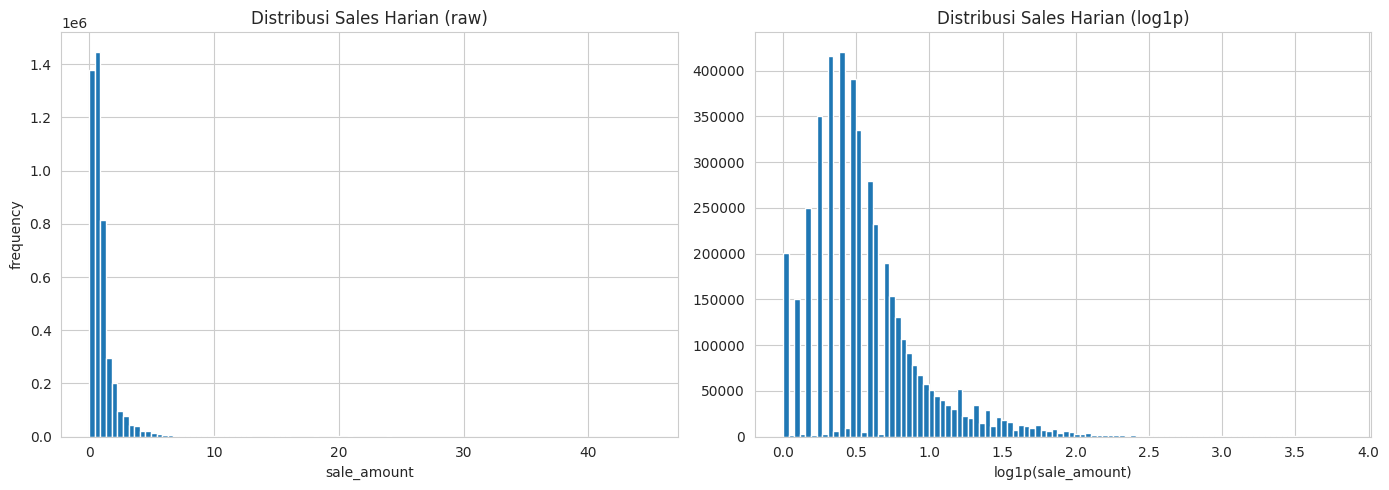

% baris dengan sale_amount = 0 : 4.46%

count    4.500000e+06
mean     9.985913e-01
std      1.406738e+00
min      0.000000e+00
25%      4.000000e-01
50%      7.000000e-01
75%      1.100000e+00
max      4.490000e+01
Name: sale_amount, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df["sale_amount"], bins=100)
axes[0].set_title("Distribusi Sales Harian (raw)")
axes[0].set_xlabel("sale_amount")
axes[0].set_ylabel("frequency")

log_sales = np.log1p(train_df["sale_amount"])
axes[1].hist(log_sales, bins=100)
axes[1].set_title("Distribusi Sales Harian (log1p)")
axes[1].set_xlabel("log1p(sale_amount)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/eda1_sales_distribution.png", dpi=150)
plt.show()

zero_sales_pct = (train_df["sale_amount"] == 0).mean() * 100
print(f"% baris dengan sale_amount = 0 : {zero_sales_pct:.2f}%")
print()
print(train_df["sale_amount"].describe())


## EDA 2 — Stockout Frequency



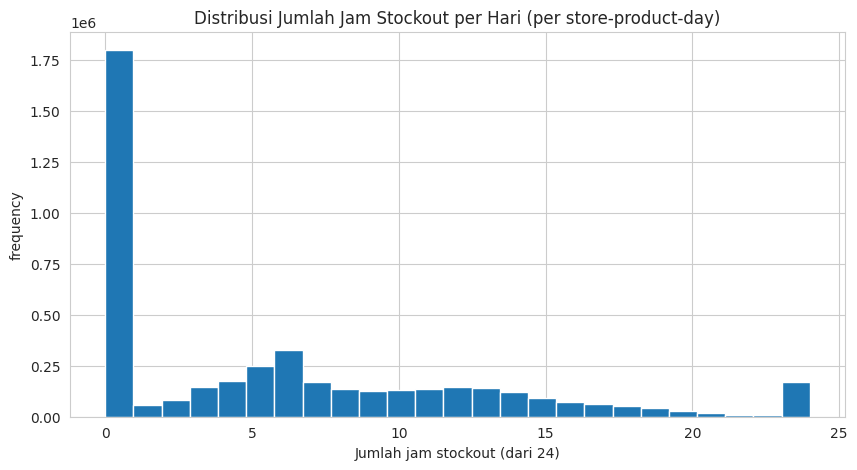

% hari TANPA stockout sama sekali : 39.98%
% hari dengan stockout SEBAGIAN    : 56.22%
% hari stockout PENUH 24 jam       : 3.79%
% hari dengan MINIMAL 1 jam stockout: 60.02%


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_df["stockout_hours"], bins=25)
ax.set_title("Distribusi Jumlah Jam Stockout per Hari (per store-product-day)")
ax.set_xlabel("Jumlah jam stockout (dari 24)")
ax.set_ylabel("frequency")
plt.savefig(f"{OUTPUT_PATH}/eda2_stockout_freq.png", dpi=150)
plt.show()

pct_no_stockout = (train_df["stockout_hours"] == 0).mean() * 100
pct_full_stockout = (train_df["stockout_hours"] == 24).mean() * 100
pct_any_stockout = (train_df["stockout_hours"] > 0).mean() * 100

print(f"% hari TANPA stockout sama sekali : {pct_no_stockout:.2f}%")
print(f"% hari dengan stockout SEBAGIAN    : {100 - pct_no_stockout - pct_full_stockout:.2f}%")
print(f"% hari stockout PENUH 24 jam       : {pct_full_stockout:.2f}%")
print(f"% hari dengan MINIMAL 1 jam stockout: {pct_any_stockout:.2f}%")


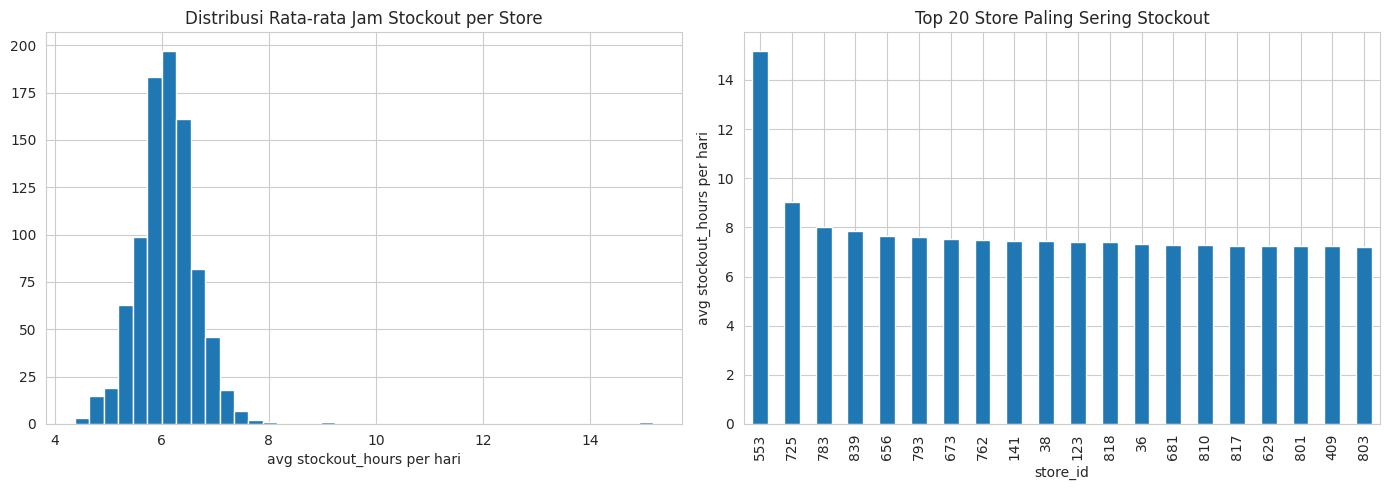

Store dengan stockout tertinggi:
store_id
553    15.177778
725     9.038095
783     8.025926
839     7.855556
656     7.636508
793     7.609524
673     7.509524
762     7.493122
141     7.450000
38      7.426984
Name: stockout_hours, dtype: float64

Store dengan stockout terendah:
store_id
578    4.747190
161    4.740419
191    4.737707
288    4.722093
658    4.714184
713    4.653488
417    4.650121
221    4.624172
202    4.579958
722    4.377205
Name: stockout_hours, dtype: float64


In [7]:
stockout_by_store = (
    train_df.groupby("store_id")["stockout_hours"]
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(stockout_by_store, bins=40)
axes[0].set_title("Distribusi Rata-rata Jam Stockout per Store")
axes[0].set_xlabel("avg stockout_hours per hari")

stockout_by_store.head(20).plot(kind="bar", ax=axes[1])
axes[1].set_title("Top 20 Store Paling Sering Stockout")
axes[1].set_ylabel("avg stockout_hours per hari")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/eda2b_stockout_by_store.png", dpi=150)
plt.show()

print("Store dengan stockout tertinggi:")
print(stockout_by_store.head(10))
print()
print("Store dengan stockout terendah:")
print(stockout_by_store.tail(10))


## EDA 3 — Stockout Duration


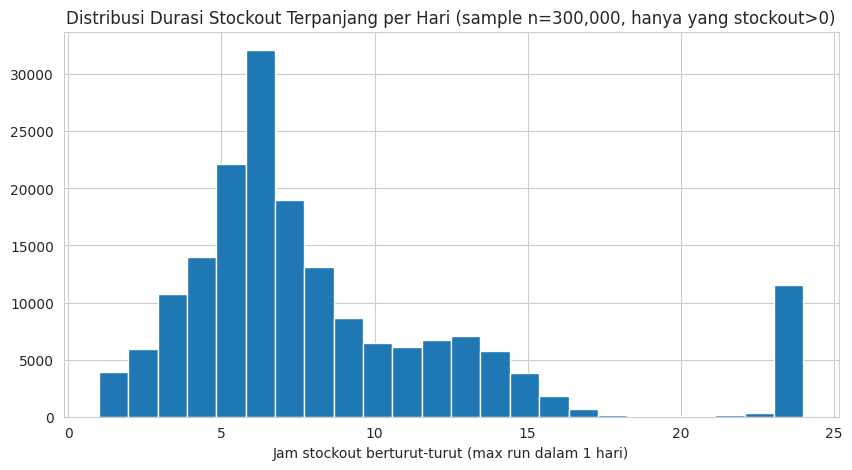

Rata-rata durasi stockout terpanjang (hari dgn stockout>0): 8.31
Median  : 7.0
P90     : 15.0


In [8]:
def max_consecutive_stockout(row):
    """Durasi run terpanjang dari nilai 1 berturut-turut dalam satu array 24 jam."""
    max_run = 0
    current = 0
    for v in row:
        if v == 1:
            current += 1
            if current > max_run:
                max_run = current
        else:
            current = 0
    return max_run

# gunakan sample untuk efisiensi (apply_along_axis relatif lambat untuk 4.5 juta baris)
SAMPLE_N = 300_000
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(stock_matrix), size=SAMPLE_N, replace=False)
sample_stock = stock_matrix[sample_idx]

max_runs = np.apply_along_axis(max_consecutive_stockout, 1, sample_stock)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(max_runs[max_runs > 0], bins=24)
ax.set_title(f"Distribusi Durasi Stockout Terpanjang per Hari (sample n={SAMPLE_N:,}, hanya yang stockout>0)")
ax.set_xlabel("Jam stockout berturut-turut (max run dalam 1 hari)")
plt.savefig(f"{OUTPUT_PATH}/eda3_stockout_duration.png", dpi=150)
plt.show()

nonzero_runs = max_runs[max_runs > 0]
print("Rata-rata durasi stockout terpanjang (hari dgn stockout>0):", nonzero_runs.mean().round(2))
print("Median  :", np.median(nonzero_runs))
print("P90     :", np.percentile(nonzero_runs, 90))


##Sales Sebelum Stockout & Sesudah Restock



In [9]:
def find_transitions(stock_row):
    """Cari titik transisi 0->1 (onset stockout) dan 1->0 (recovery) dalam satu array 24 jam.
    Hanya menangkap transisi DALAM hari yang sama (tidak menyambung ke hari sebelum/sesudahnya)."""
    onsets = []
    recoveries = []
    for i in range(1, 24):
        if stock_row[i - 1] == 0 and stock_row[i] == 1:
            onsets.append(i)
        if stock_row[i - 1] == 1 and stock_row[i] == 0:
            recoveries.append(i)
    return onsets, recoveries


WINDOW = 3  # jumlah jam sebelum/sesudah transisi yang diamati

before_onset_sales = []
after_recovery_sales = []

SAMPLE_N2 = 150_000
rng2 = np.random.RandomState(1)
sample_idx2 = rng2.choice(len(sales_matrix), size=SAMPLE_N2, replace=False)

for idx in sample_idx2:
    s_row = sales_matrix[idx]
    st_row = stock_matrix[idx]
    onsets, recoveries = find_transitions(st_row)

    for onset in onsets:
        start = max(0, onset - WINDOW)
        if start < onset:
            before_onset_sales.append(s_row[start:onset])

    for rec in recoveries:
        end = min(24, rec + WINDOW)
        if rec < end:
            after_recovery_sales.append(s_row[rec:end])

print(f"Jumlah episode onset stockout ditemukan   : {len(before_onset_sales):,}")
print(f"Jumlah episode recovery/restock ditemukan : {len(after_recovery_sales):,}")


Jumlah episode onset stockout ditemukan   : 65,035
Jumlah episode recovery/restock ditemukan : 64,005


In [10]:
def align_and_average(list_of_arrays, window, direction):
    """Ratakan array dengan panjang variatif ke shape (n, window).
    direction='before' -> align ke kanan (index -1 = jam tepat sebelum transisi)
    direction='after'  -> align ke kiri  (index  0 = jam tepat pada/setelah transisi)"""
    arr = np.full((len(list_of_arrays), window), np.nan)
    for i, a in enumerate(list_of_arrays):
        if direction == "before":
            arr[i, -len(a):] = a
        else:
            arr[i, :len(a)] = a
    return np.nanmean(arr, axis=0)


avg_before = align_and_average(before_onset_sales, WINDOW, "before")
avg_after = align_and_average(after_recovery_sales, WINDOW, "after")

baseline_sales = sales_matrix[stock_matrix == 0].mean()

print("Rata-rata sales, 3 jam SEBELUM stockout dimulai :", np.round(avg_before, 5))
print("Rata-rata sales, 3 jam SETELAH restock           :", np.round(avg_after, 5))
print("Baseline rata-rata sales (semua jam non-stockout):", round(baseline_sales, 5))


Rata-rata sales, 3 jam SEBELUM stockout dimulai : [0.11129 0.12188 0.17878]
Rata-rata sales, 3 jam SETELAH restock           : [0.03222 0.05028 0.07166]
Baseline rata-rata sales (semua jam non-stockout): 0.054


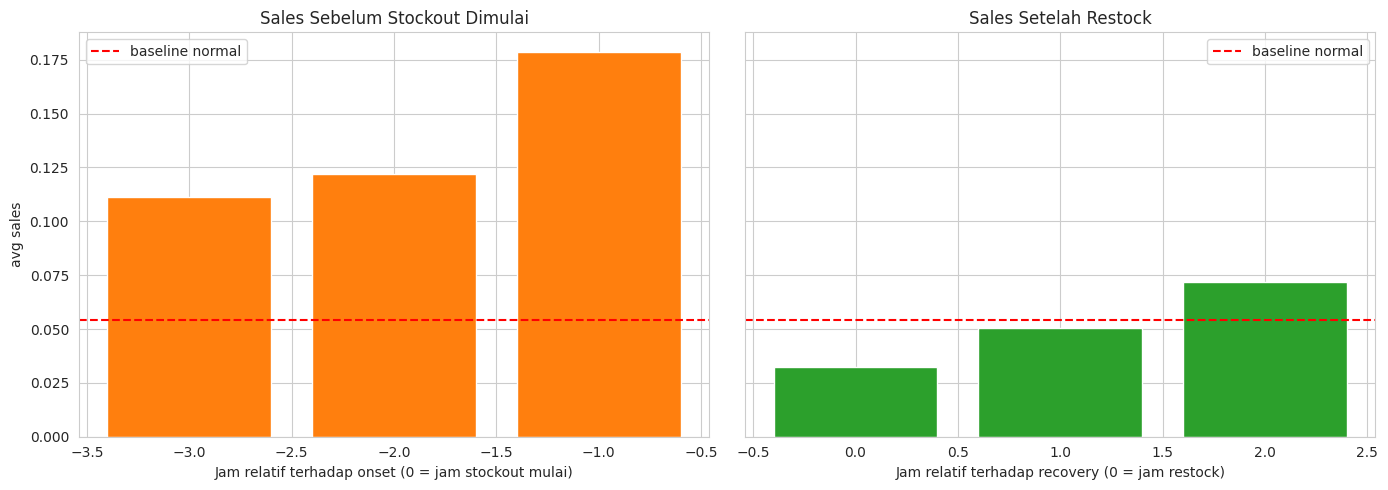

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].bar(range(-WINDOW, 0), avg_before, color="tab:orange")
axes[0].axhline(baseline_sales, color="red", linestyle="--", label="baseline normal")
axes[0].set_title("Sales Sebelum Stockout Dimulai")
axes[0].set_xlabel("Jam relatif terhadap onset (0 = jam stockout mulai)")
axes[0].set_ylabel("avg sales")
axes[0].legend()

axes[1].bar(range(0, WINDOW), avg_after, color="tab:green")
axes[1].axhline(baseline_sales, color="red", linestyle="--", label="baseline normal")
axes[1].set_title("Sales Setelah Restock")
axes[1].set_xlabel("Jam relatif terhadap recovery (0 = jam restock)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/eda4_5_ghost_demand_evidence.png", dpi=150)
plt.show()


## EDA 6 — Demand by Hour



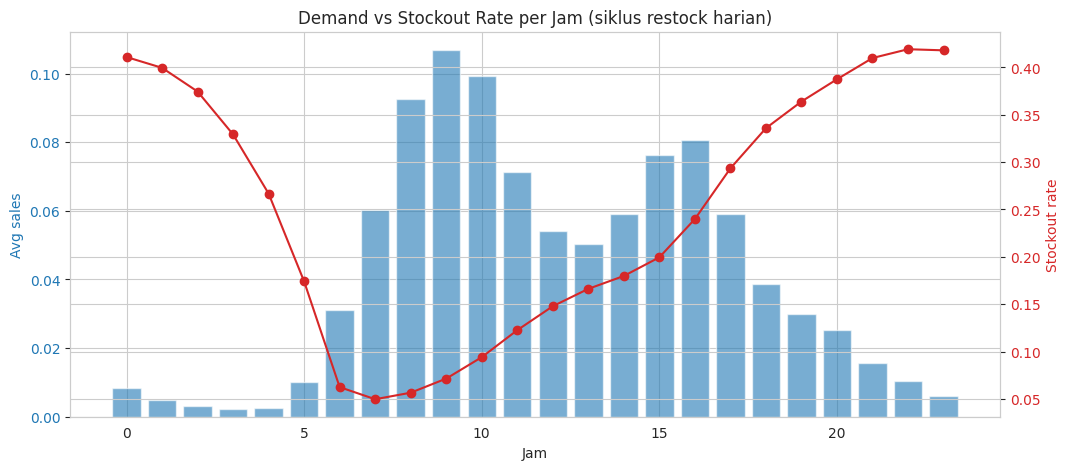

Jam dengan stockout rate TERENDAH (kemungkinan waktu restock): 07:00
Jam dengan demand TERTINGGI: 09:00


In [12]:
avg_sales_per_hour = sales_matrix.mean(axis=0)
avg_stockout_per_hour = stock_matrix.mean(axis=0)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(range(24), avg_sales_per_hour, alpha=0.6, color="tab:blue", label="avg sales")
ax1.set_xlabel("Jam")
ax1.set_ylabel("Avg sales", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(range(24), avg_stockout_per_hour, color="tab:red", marker="o", label="stockout rate")
ax2.set_ylabel("Stockout rate", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Demand vs Stockout Rate per Jam (siklus restock harian)")
plt.savefig(f"{OUTPUT_PATH}/eda6_demand_by_hour.png", dpi=150)
plt.show()

jam_restock_optimal = int(np.argmin(avg_stockout_per_hour))
jam_demand_puncak = int(np.argmax(avg_sales_per_hour))
print(f"Jam dengan stockout rate TERENDAH (kemungkinan waktu restock): {jam_restock_optimal:02d}:00")
print(f"Jam dengan demand TERTINGGI: {jam_demand_puncak:02d}:00")


## EDA 7 — Demand by Weekday

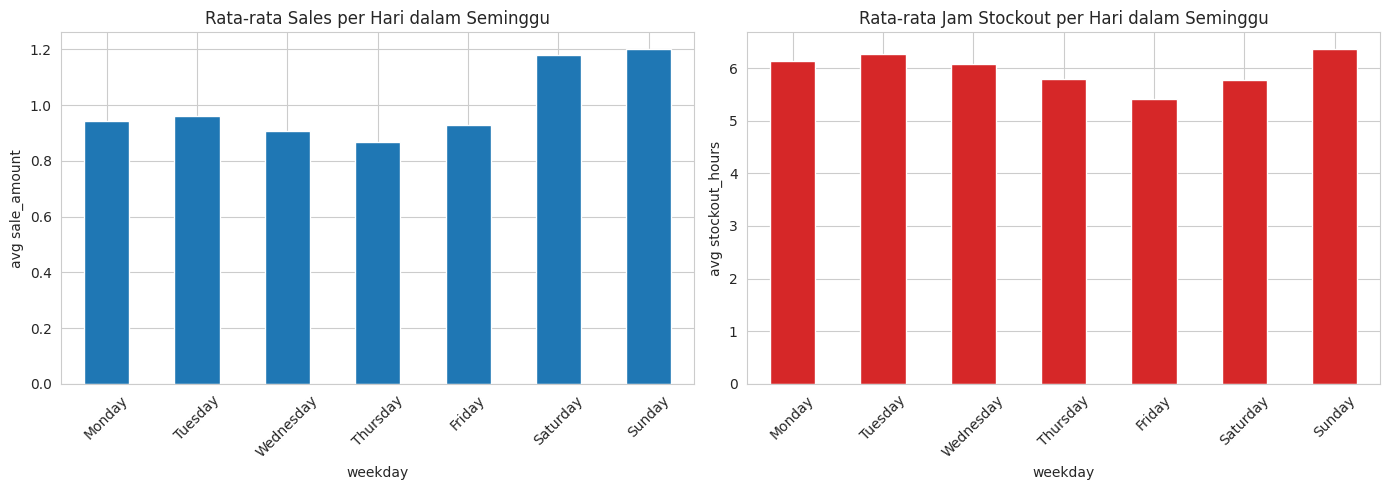

           avg_sales  avg_stockout_hours
weekday                                 
Monday      0.942580            6.134540
Tuesday     0.961985            6.264758
Wednesday   0.906884            6.084322
Thursday    0.866036            5.788995
Friday      0.926775            5.404860
Saturday    1.178130            5.778612
Sunday      1.200694            6.360251


In [13]:
train_df["weekday"] = train_df["dt"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

demand_by_weekday = (
    train_df.groupby("weekday")["sale_amount"]
    .mean()
    .reindex(weekday_order)
)
stockout_by_weekday = (
    train_df.groupby("weekday")["stockout_hours"]
    .mean()
    .reindex(weekday_order)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

demand_by_weekday.plot(kind="bar", ax=axes[0], color="tab:blue")
axes[0].set_title("Rata-rata Sales per Hari dalam Seminggu")
axes[0].set_ylabel("avg sale_amount")
axes[0].tick_params(axis="x", rotation=45)

stockout_by_weekday.plot(kind="bar", ax=axes[1], color="tab:red")
axes[1].set_title("Rata-rata Jam Stockout per Hari dalam Seminggu")
axes[1].set_ylabel("avg stockout_hours")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/eda7_demand_by_weekday.png", dpi=150)
plt.show()

print(pd.DataFrame({"avg_sales": demand_by_weekday, "avg_stockout_hours": stockout_by_weekday}))


## EDA 8 — Demand vs Promotion

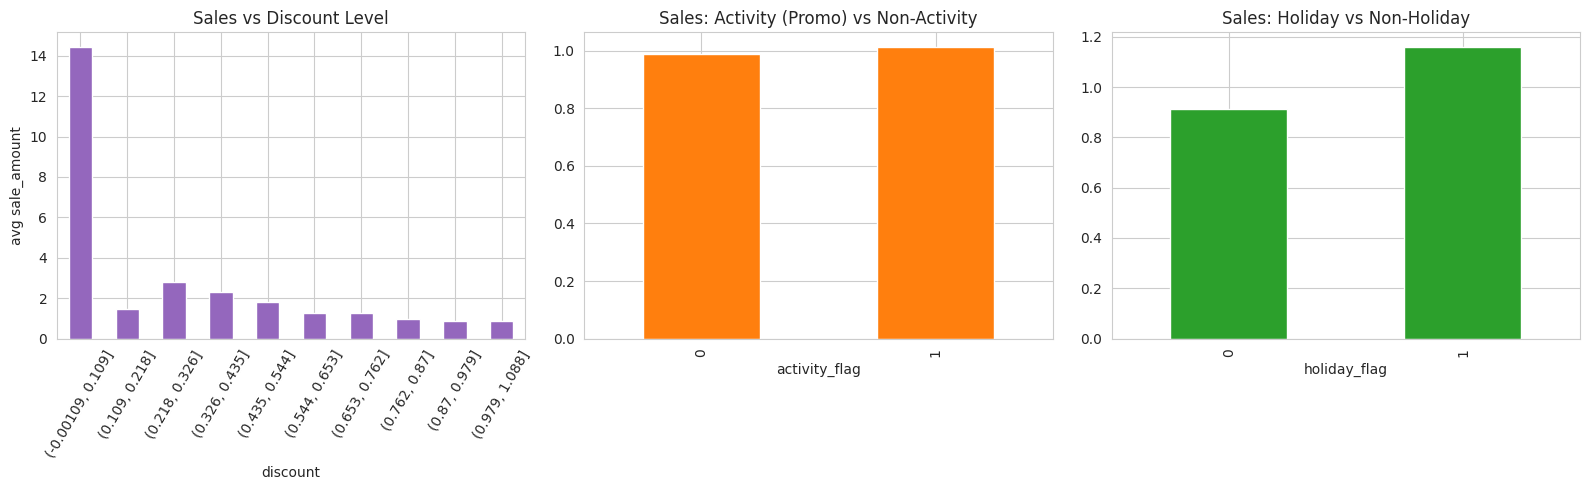

Sales rata-rata (activity_flag):
activity_flag
0    0.989662
1    1.013258
Name: sale_amount, dtype: float64

Sales rata-rata (holiday_flag):
holiday_flag
0    0.913969
1    1.159647
Name: sale_amount, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

discount_bins = pd.cut(train_df["discount"], bins=10)
train_df.groupby(discount_bins, observed=True)["sale_amount"].mean().plot(kind="bar", ax=axes[0], color="tab:purple")
axes[0].set_title("Sales vs Discount Level")
axes[0].set_ylabel("avg sale_amount")
axes[0].tick_params(axis="x", rotation=60)

train_df.groupby("activity_flag")["sale_amount"].mean().plot(kind="bar", ax=axes[1], color="tab:orange")
axes[1].set_title("Sales: Activity (Promo) vs Non-Activity")
axes[1].set_xlabel("activity_flag")

train_df.groupby("holiday_flag")["sale_amount"].mean().plot(kind="bar", ax=axes[2], color="tab:green")
axes[2].set_title("Sales: Holiday vs Non-Holiday")
axes[2].set_xlabel("holiday_flag")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/eda8_demand_vs_promotion.png", dpi=150)
plt.show()

print("Sales rata-rata (activity_flag):")
print(train_df.groupby("activity_flag")["sale_amount"].mean())
print()
print("Sales rata-rata (holiday_flag):")
print(train_df.groupby("holiday_flag")["sale_amount"].mean())


In [15]:
# Bonus: apakah promosi/aktivitas juga berkorelasi dengan stockout?
# (kalau promo meningkatkan demand tapi toko tidak menambah stok, promo bisa JADI PENYEBAB stockout)
print("Rata-rata jam stockout (activity_flag):")
print(train_df.groupby("activity_flag")["stockout_hours"].mean())
print()
print("Rata-rata jam stockout (holiday_flag):")
print(train_df.groupby("holiday_flag")["stockout_hours"].mean())


Rata-rata jam stockout (activity_flag):
activity_flag
0    5.850679
1    6.172689
Name: stockout_hours, dtype: float64

Rata-rata jam stockout (holiday_flag):
holiday_flag
0    5.985727
1    5.947425
Name: stockout_hours, dtype: float64


## EDA 9 — Demand vs Weather

In [16]:
weather_cols = ["avg_temperature", "avg_humidity", "avg_wind_level", "precpt"]

corr_matrix = train_df[weather_cols + ["sale_amount"]].corr()
print("Korelasi terhadap sale_amount:")
print(corr_matrix["sale_amount"].sort_values(ascending=False))


Korelasi terhadap sale_amount:
sale_amount        1.000000
avg_temperature    0.056425
avg_humidity       0.043337
precpt             0.037044
avg_wind_level    -0.007699
Name: sale_amount, dtype: float64


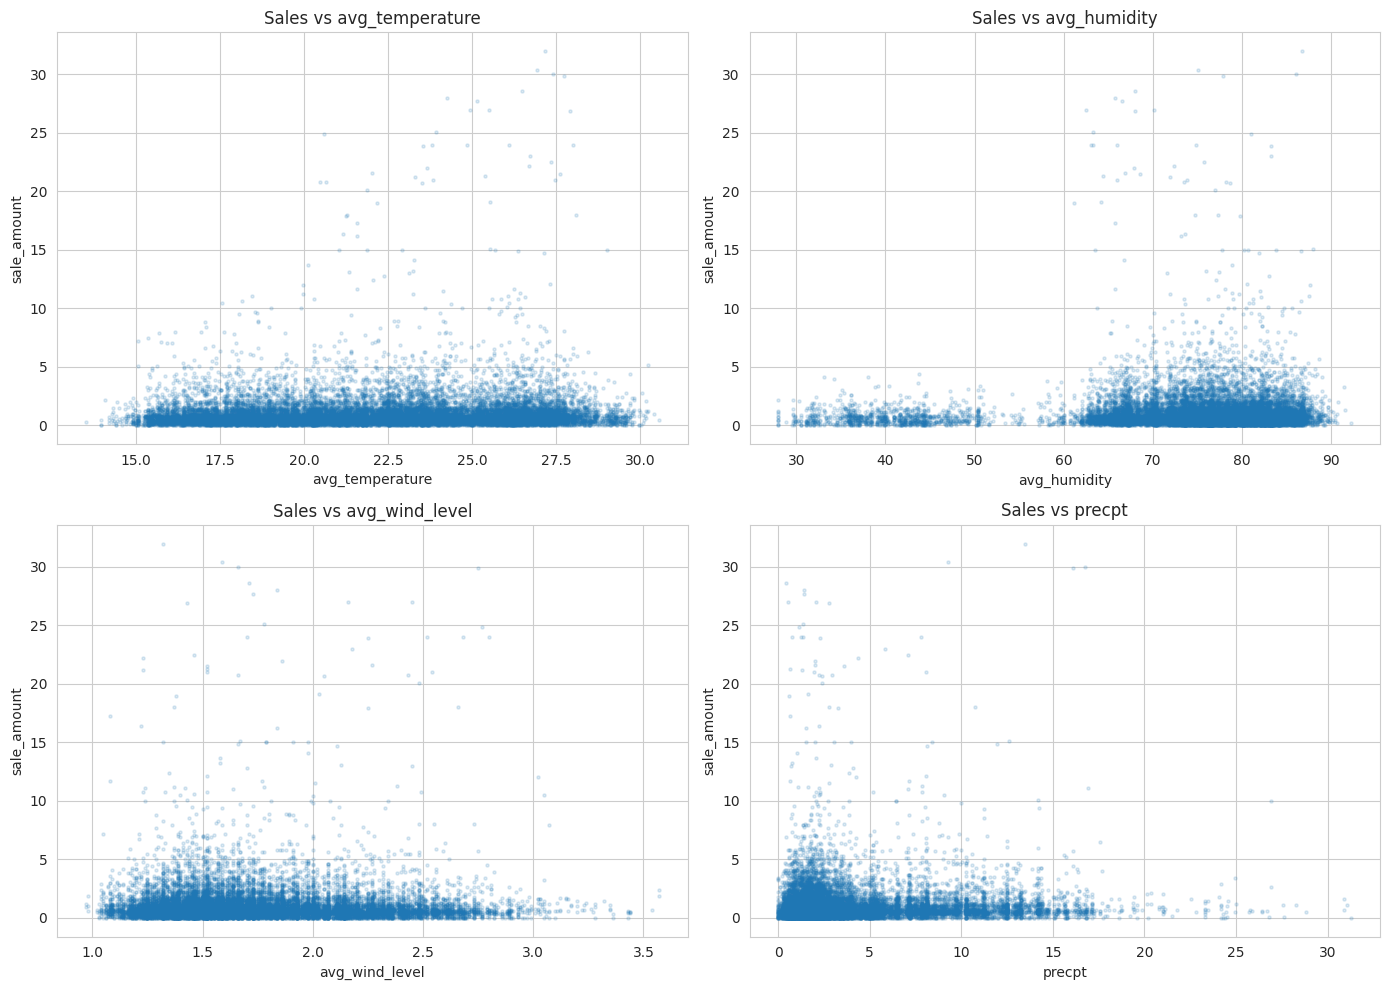

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sample_plot = train_df.sample(20_000, random_state=0)

for ax, col in zip(axes.flatten(), weather_cols):
    ax.scatter(sample_plot[col], sample_plot["sale_amount"], alpha=0.15, s=5)
    ax.set_xlabel(col)
    ax.set_ylabel("sale_amount")
    ax.set_title(f"Sales vs {col}")

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/eda9_demand_vs_weather.png", dpi=150)
plt.show()


## EDA 10 — Store / Product Heterogeneity

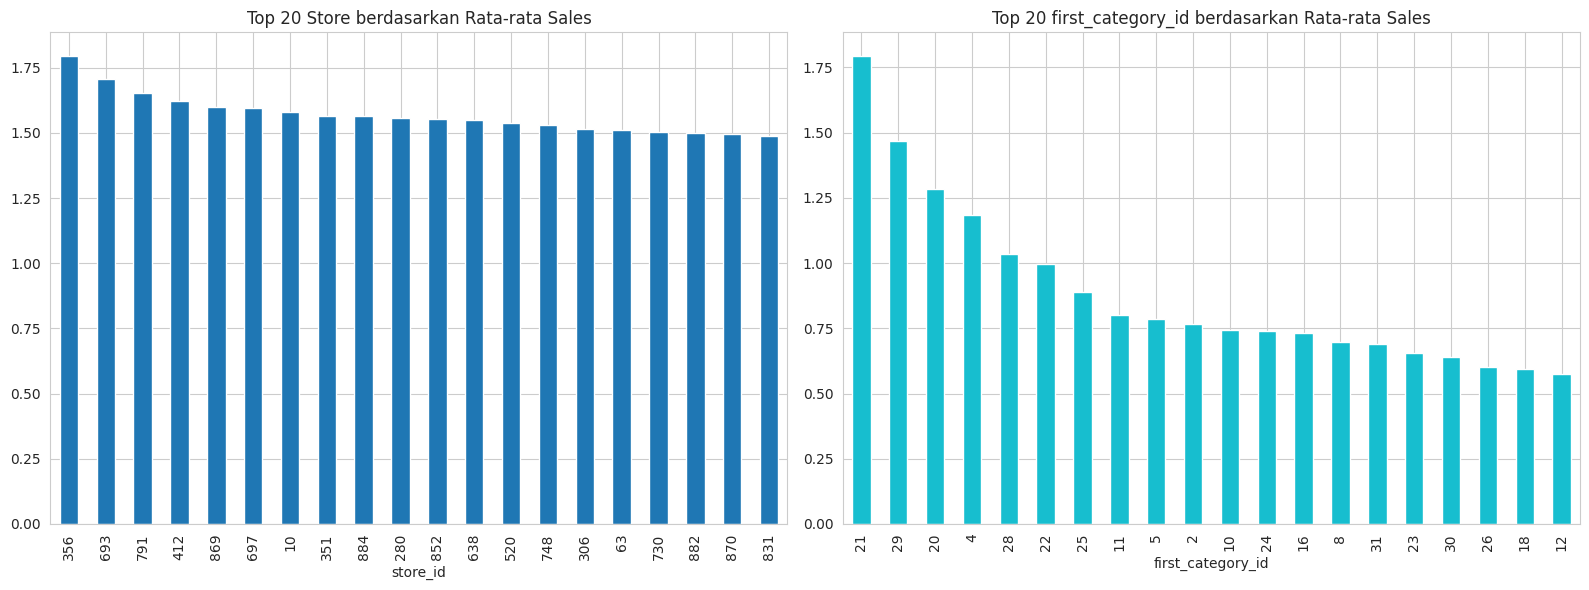

Coefficient of variation sales antar store    : 0.222
Coefficient of variation sales antar category  : 0.432


In [18]:
sales_by_store = train_df.groupby("store_id")["sale_amount"].mean().sort_values(ascending=False)
sales_by_category = train_df.groupby("first_category_id")["sale_amount"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sales_by_store.head(20).plot(kind="bar", ax=axes[0], color="tab:blue")
axes[0].set_title("Top 20 Store berdasarkan Rata-rata Sales")
axes[0].tick_params(axis="x", rotation=90)

sales_by_category.head(20).plot(kind="bar", ax=axes[1], color="tab:cyan")
axes[1].set_title("Top 20 first_category_id berdasarkan Rata-rata Sales")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/eda10_heterogeneity.png", dpi=150)
plt.show()

cv_store = sales_by_store.std() / sales_by_store.mean()
cv_category = sales_by_category.std() / sales_by_category.mean()

print(f"Coefficient of variation sales antar store    : {cv_store:.3f}")
print(f"Coefficient of variation sales antar category  : {cv_category:.3f}")


##Efek Stockout Terhadap Sales Hari Berikutnya



In [19]:
train_sorted = train_df.sort_values(["store_id", "product_id", "dt"]).copy()

train_sorted["next_day_sales"] = (
    train_sorted.groupby(["store_id", "product_id"])["sale_amount"].shift(-1)
)
train_sorted["prev_day_stockout_hours"] = (
    train_sorted.groupby(["store_id", "product_id"])["stockout_hours"].shift(1)
)

valid = train_sorted.dropna(subset=["next_day_sales", "prev_day_stockout_hours"])

corr_stockout_next = valid[["stockout_hours", "next_day_sales"]].corr().iloc[0, 1]
print("Korelasi (jam stockout HARI INI) vs (sales HARI BERIKUTNYA):", round(corr_stockout_next, 4))


Korelasi (jam stockout HARI INI) vs (sales HARI BERIKUTNYA): -0.0257


/tmp/ipykernel_2610/3921215060.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid["stockout_bucket"] = pd.cut(


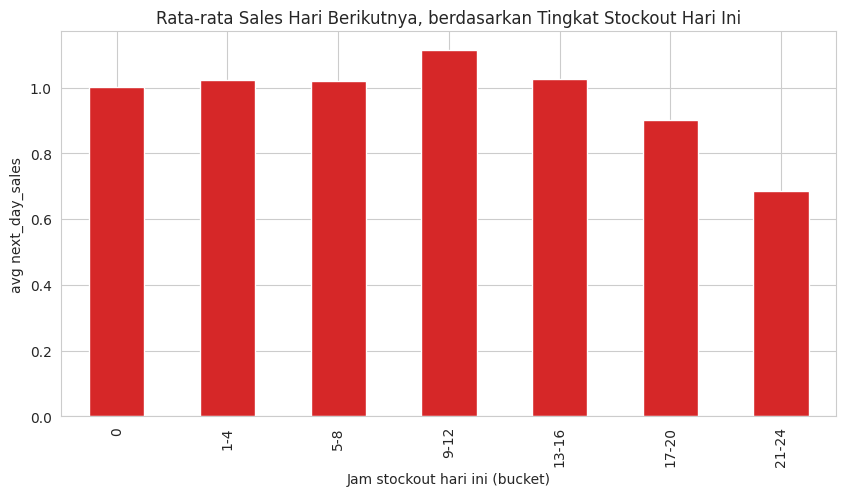

stockout_bucket
0        1.002824
1-4      1.024280
5-8      1.020031
9-12     1.114731
13-16    1.026767
17-20    0.902202
21-24    0.685559
Name: next_day_sales, dtype: float64


In [20]:
# Bandingkan rata-rata next_day_sales antar kelompok tingkat stockout hari ini
valid["stockout_bucket"] = pd.cut(
    valid["stockout_hours"],
    bins=[-1, 0, 4, 8, 12, 16, 20, 24],
    labels=["0", "1-4", "5-8", "9-12", "13-16", "17-20", "21-24"]
)

rebound_by_bucket = valid.groupby("stockout_bucket", observed=True)["next_day_sales"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
rebound_by_bucket.plot(kind="bar", ax=ax, color="tab:red")
ax.set_title("Rata-rata Sales Hari Berikutnya, berdasarkan Tingkat Stockout Hari Ini")
ax.set_xlabel("Jam stockout hari ini (bucket)")
ax.set_ylabel("avg next_day_sales")
plt.savefig(f"{OUTPUT_PATH}/ghost_demand_evidence2_next_day.png", dpi=150)
plt.show()

print(rebound_by_bucket)


In [4]:
train_df.to_parquet(f"{PROCESSED_PATH}/train_daily_enriched.parquet", index=False)
eval_df.to_parquet(f"{PROCESSED_PATH}/eval_daily_enriched.parquet", index=False)

print("Tersimpan:")
print(f"- {PROCESSED_PATH}/train_daily_enriched.parquet")
print(f"- {PROCESSED_PATH}/eval_daily_enriched.parquet")


Tersimpan:
- /content/drive/MyDrive/Reflow/data/processed/train_daily_enriched.parquet
- /content/drive/MyDrive/Reflow/data/processed/eval_daily_enriched.parquet
